### IMPORTS

In [1]:
import os
import numpy
import matplotlib.pyplot as plot
import seaborn
import tensorflow
import json
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### REPRODUCIBILITY

In [2]:
numpy.random.seed(42)
tensorflow.random.set_seed(42)

### SET PARAMETERS

In [3]:
image_height = 224
image_width = 224

training_directory = "../data/brain_tumor/training"
testing_directory = "../data/brain_tumor/testing"

### DATA AUGMENTATION

In [4]:
training_augmenter = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.1,
    brightness_range=[0.8, 1.2])

validation_augmenter = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2)

testing_augmenter = ImageDataGenerator(
    rescale=1.0 / 255)

### DATA LOADERS

In [5]:
training_loader = training_augmenter.flow_from_directory(
    training_directory,
    target_size=(image_height, image_width),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True)

validation_loader = validation_augmenter.flow_from_directory(
    training_directory,
    target_size=(image_height, image_width),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False)

testing_loader = testing_augmenter.flow_from_directory(
    testing_directory,
    target_size=(image_height, image_width),
    batch_size=32,
    class_mode="categorical",
    shuffle=False)

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


### CLASS WEIGHTS

In [6]:
training_labels = training_loader.classes
label_names = list(training_loader.class_indices.keys())

class_weight_values = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=numpy.unique(training_labels),
    y=training_labels)

class_weights = dict(enumerate(class_weight_values))
print("Class weights:", class_weights)

Class weights: {0: 1.0811258278145695, 1: 1.0659981343283582, 2: 0.8955721003134797, 3: 0.9800600343053173}


### STEPS

In [7]:
steps_per_epoch = training_loader.samples // 32
validation_steps = validation_loader.samples // 32

### BUILD MODEL

In [8]:
def build_cnn(input_shape=(224, 224, 3), num_classes=4):
    model_network = models.Sequential()

    model_network.add(layers.Conv2D(
        32, (3, 3), padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(0.001),
        input_shape=input_shape
    ))
    model_network.add(layers.BatchNormalization())
    model_network.add(layers.MaxPooling2D((2, 2)))

    model_network.add(layers.Conv2D(
        64, (3, 3), padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ))
    model_network.add(layers.BatchNormalization())
    model_network.add(layers.MaxPooling2D((2, 2)))

    model_network.add(layers.Conv2D(
        128, (3, 3), padding="same", activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    ))
    model_network.add(layers.BatchNormalization())
    model_network.add(layers.MaxPooling2D((2, 2)))

    model_network.add(layers.GlobalAveragePooling2D())
    model_network.add(layers.Dense(128, activation="relu"))
    model_network.add(layers.Dropout(0.6))
    model_network.add(layers.Dense(num_classes, activation="softmax"))

    model_network.compile(
        optimizer=tensorflow.keras.optimizers.Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"])

    return model_network

### CREATE MODEL

In [9]:
model_network = build_cnn(input_shape=(image_height, image_width, 3), num_classes=len(label_names))
model_network.summary()

/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

### CALLBACKS

In [10]:
callback_list = [
    EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1)]

### TRAIN MODEL

In [11]:
training_history = model_network.fit(
    training_loader,
    steps_per_epoch=steps_per_epoch,
    epochs=35,
    validation_data=validation_loader,
    validation_steps=validation_steps,
    callbacks=callback_list,
    class_weight=class_weights,
    verbose=1)

/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 304s 2s/step - accuracy: 0.4738 - loss: 1.3044 - val_accuracy: 0.2411 - val_loss: 1.5769 - learning_rate: 1.0000e-04
Epoch 2/30
  1/142 ━━━━━━━━━━━━━━━━━━━━ 4:54 2s/step - accuracy: 0.5000 - loss: 1.2008

/Users/radhamurugan/anaconda3/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


142/142 ━━━━━━━━━━━━━━━━━━━━ 17s 107ms/step - accuracy: 0.5000 - loss: 1.2008 - val_accuracy: 0.2411 - val_loss: 1.5779 - learning_rate: 1.0000e-04
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.6358 - loss: 1.0457 - val_accuracy: 0.2411 - val_loss: 1.6400 - learning_rate: 1.0000e-04
Epoch 4/30
  1/142 ━━━━━━━━━━━━━━━━━━━━ 4:36 2s/step - accuracy: 0.5938 - loss: 1.0495
Epoch 4: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
142/142 ━━━━━━━━━━━━━━━━━━━━ 17s 109ms/step - accuracy: 0.5938 - loss: 1.0495 - val_accuracy: 0.2411 - val_loss: 1.6404 - learning_rate: 1.0000e-04
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.6639 - loss: 0.9802 - val_accuracy: 0.3473 - val_loss: 1.4213 - learning_rate: 3.0000e-05
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step - accuracy: 0.5625 - loss: 1.1419 - val_accuracy: 0.3509 - val_loss: 1.4204 - learning_rate: 3.0000e-05
Epoch 7/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 303s 2s/step - accuracy: 0.

### SAVE OUTPUTS

In [12]:
saved_directory = "../saved"
os.makedirs(saved_directory, exist_ok=True)

model_network.save(os.path.join(saved_directory, "cnn_model.h5"))

with open(os.path.join(saved_directory, "cnn_class_names.json"), "w") as file_output:
    json.dump(label_names, file_output)

with open(os.path.join(saved_directory, "cnn_training_history.json"), "w") as file_output:
    json.dump(training_history.history, file_output)

print("All files saved successfully in:", saved_directory)

All files saved successfully in: ../saved


### ACCURACY AND LOSS PLOT

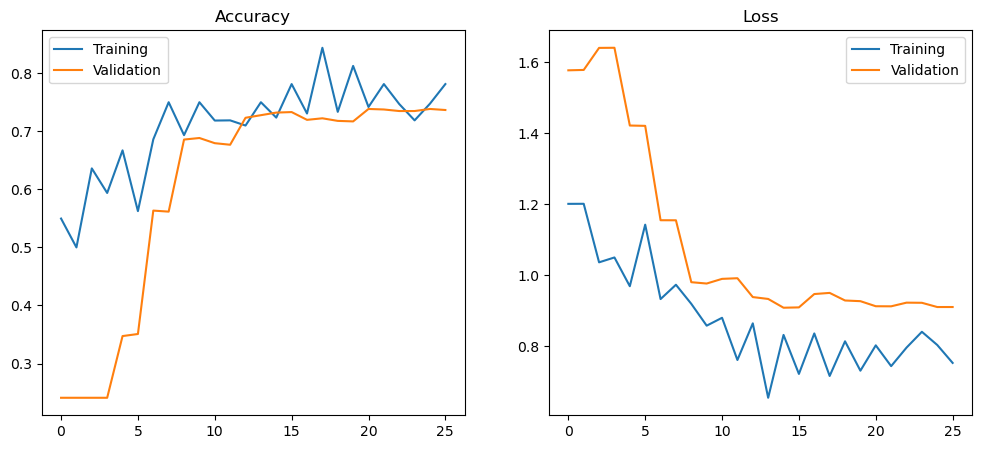

In [13]:
plot.figure(figsize=(12, 5))

plot.subplot(1, 2, 1)
plot.plot(training_history.history["accuracy"], label="Training")
plot.plot(training_history.history["val_accuracy"], label="Validation")
plot.title("Accuracy")
plot.legend()

plot.subplot(1, 2, 2)
plot.plot(training_history.history["loss"], label="Training")
plot.plot(training_history.history["val_loss"], label="Validation")
plot.title("Loss")
plot.legend()

plot.show()

### CONFUSION MATRIX

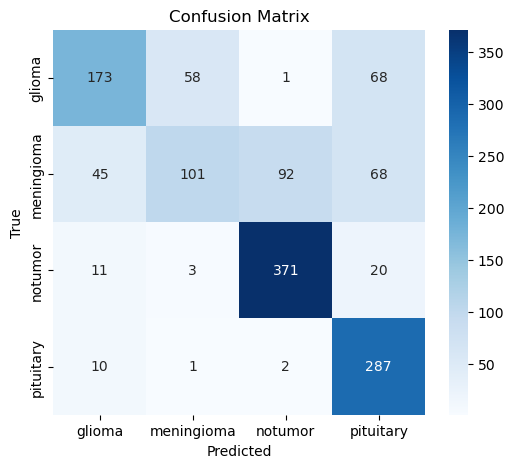

In [14]:
testing_loader.reset()
predicted_labels = numpy.argmax(
    model_network.predict(testing_loader, verbose=0),
    axis=1)

true_labels = testing_loader.classes

confusion_matrix_values = confusion_matrix(true_labels, predicted_labels)

plot.figure(figsize=(6, 5))
seaborn.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names)
plot.xlabel("Predicted")
plot.ylabel("True")
plot.title("Confusion Matrix")
plot.show()

### Classification Report

In [15]:
print("Classification Report:")
print(classification_report(true_labels, predicted_labels, target_names=label_names))
print("Test Accuracy:", accuracy_score(true_labels, predicted_labels))

Classification Report:
              precision    recall  f1-score   support

      glioma       0.72      0.58      0.64       300
  meningioma       0.62      0.33      0.43       306
     notumor       0.80      0.92      0.85       405
   pituitary       0.65      0.96      0.77       300

    accuracy                           0.71      1311
   macro avg       0.70      0.69      0.67      1311
weighted avg       0.70      0.71      0.69      1311

Test Accuracy: 0.7109077040427155
